# ❤️ Heart Disease Prediction Using Machine Learning

## Introduction

Heart disease is an important health problem, and machine learning can be used to identify patterns in patient data.

In this project, I used patient health information to build a machine learning classification model that predicts whether a patient has heart disease or not.

### 🛠️ Tools & Technologies

- **Python**
- **NumPy**
- **Pandas**
- **Matplotlib**
- **Seaborn**
- **Scikit-learn**
- **XGBoost**
- **Kaggle**

### 📋 Dataset Features

The dataset contains **918 patient records and 12 columns**.

The main features include:

- **Age** – Patient's age
- **Sex** – Patient's gender
- **ChestPainType** – Type of chest pain
- **RestingBP** – Resting blood pressure
- **Cholesterol** – Cholesterol level
- **FastingBS** – Fasting blood sugar
- **RestingECG** – Resting ECG results
- **MaxHR** – Maximum heart rate
- **ExerciseAngina** – Exercise-induced angina
- **Oldpeak** – ST depression
- **ST_Slope** – Slope of the peak exercise ST segment
- **HeartDisease** – Target variable (`1` = Heart Disease, `0` = Normal)

## Importing Required Libraries

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Loading

In [2]:
path='/kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv'
df=pd.read_csv(path)

## Understanding Dataset

In [3]:
df.shape

(918, 12)

In [4]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

## Explorartory Data Analysis

In [10]:
cat_cols=df.select_dtypes(include='object').columns.tolist()
num_cols=df.select_dtypes(exclude='object').columns.tolist()
num_cols.remove('HeartDisease')

In [11]:
cat_cols.append('HeartDisease')

In [12]:
print("Categorical Columns:",cat_cols)
print("Numerical Columns:",num_cols)

Categorical Columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']
Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


## Target Variable Distribution

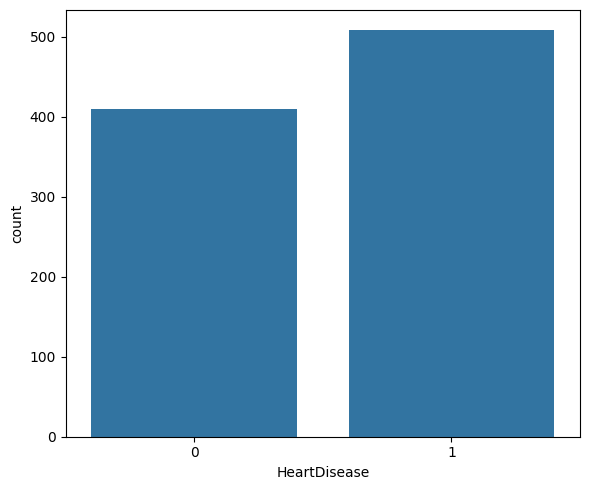

In [13]:
fig,ax=plt.subplots(1,figsize=(6,5))
sns.countplot(x=df['HeartDisease'],)
plt.tight_layout()
plt.show()


## Distribution of Numerical Features

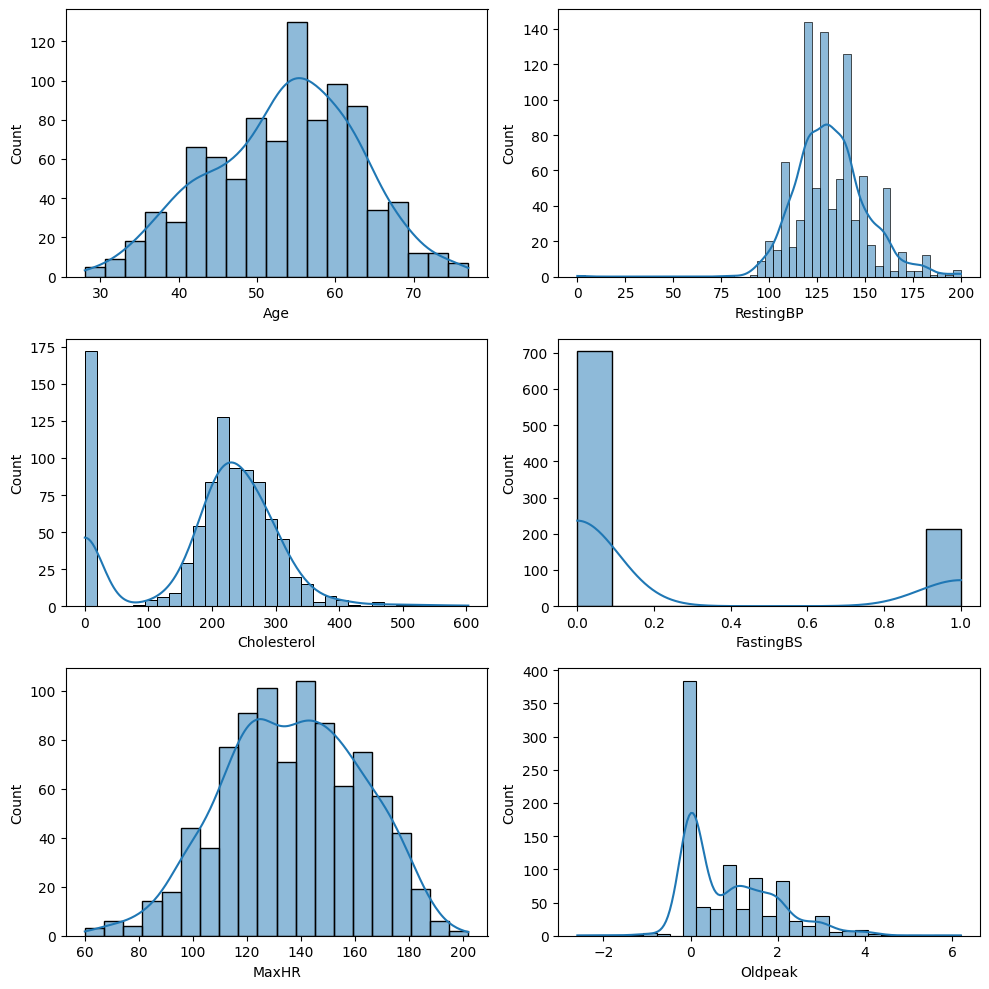

In [14]:
fig,ax=plt.subplots(3,2,figsize=(10,10))
ax=ax.flatten()
for i,col in enumerate(num_cols):
    sns.histplot(x=df[col],ax=ax[i],kde=True)
plt.tight_layout()
plt.show()


## Boxplot Analysis

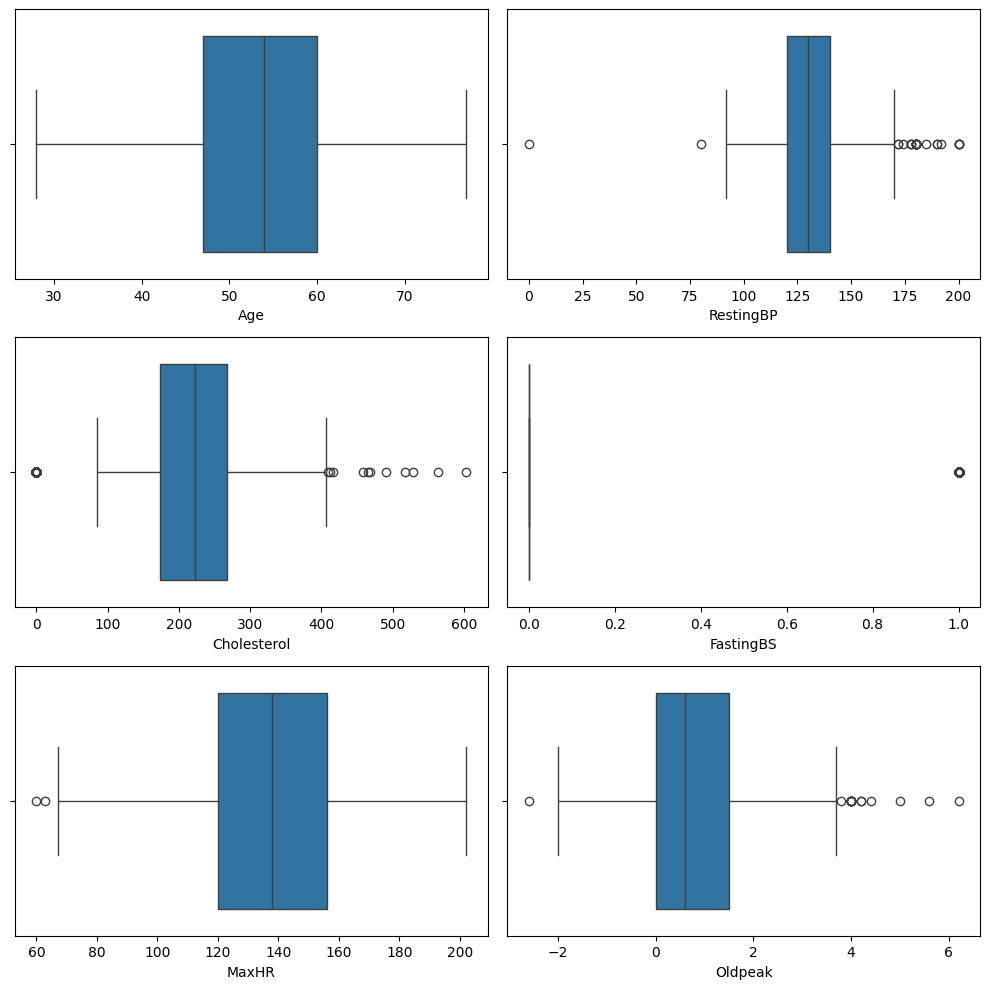

In [15]:
fig,ax=plt.subplots(3,2,figsize=(10,10))
ax=ax.flatten()
for i,col in enumerate(num_cols):
    sns.boxplot(x=df[col],ax=ax[i],vert=False)
plt.tight_layout()
plt.show()


##  Categorical Feature Analysis

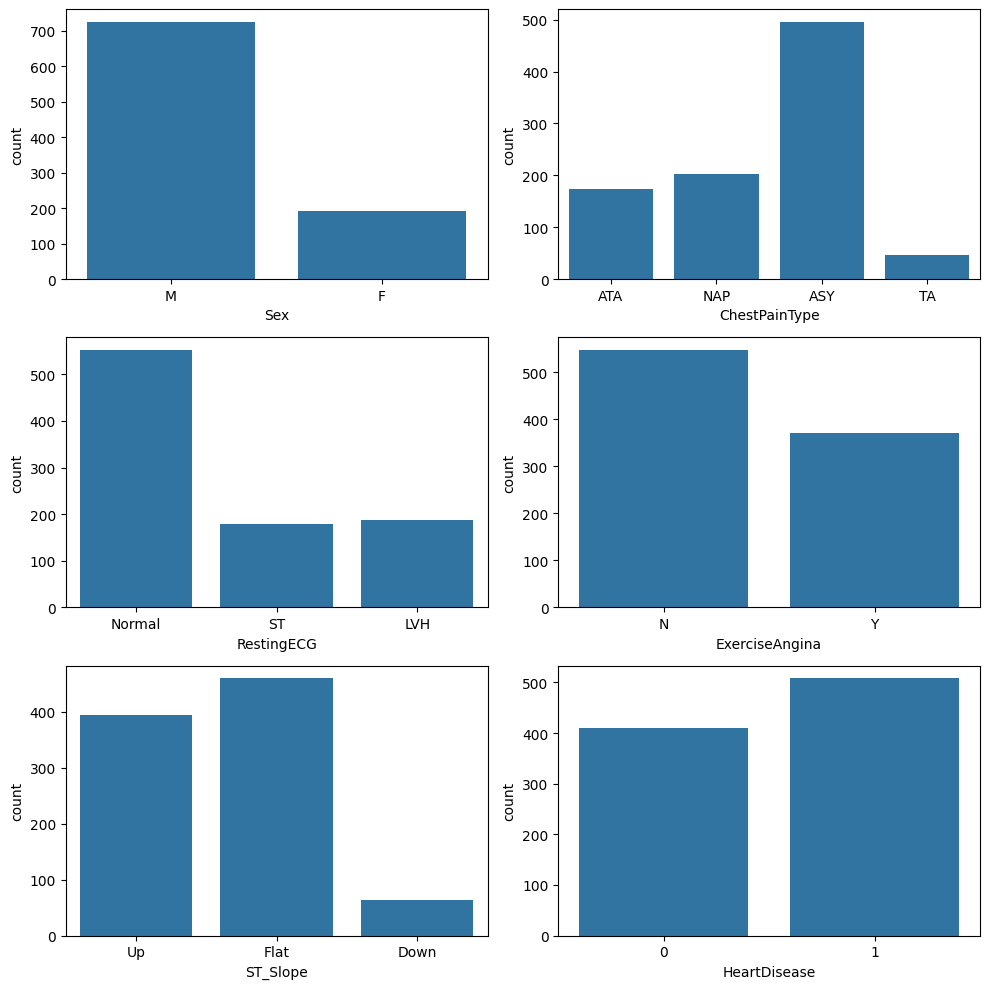

In [16]:
fig,ax=plt.subplots(3,2,figsize=(10,10))
ax=ax.flatten()
for i,col in enumerate(cat_cols):
    sns.countplot(x=df[col],ax=ax[i])
plt.tight_layout()
plt.show()


##  Correlation Analysis

<Axes: >

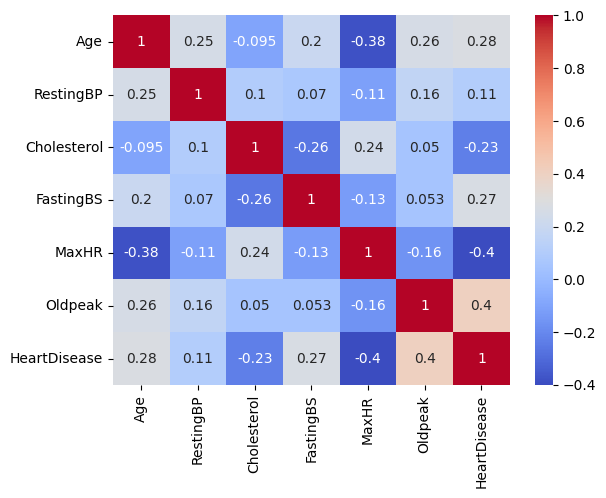

In [17]:
corr_matrix=df.select_dtypes('number').corr()
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')

## Data Preprocessing

In [18]:
from sklearn.model_selection import train_test_split,StratifiedKFold,GridSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix

## Separating Features and Target

In [19]:
X=df.drop('HeartDisease',axis=1)
y=df['HeartDisease']

## Splitting the Dataset

In [20]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

### Training and Testing Data Size

In [21]:
print("Training Data Shape:",X_train.shape)
print("Testing Data Shape:",X_test.shape)

Training Data Shape: (734, 11)
Testing Data Shape: (184, 11)


In [22]:
categorical_features=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']
numerical_features=['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

## Preprocessing Pipelines

In [23]:
numerical_pipe=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='mean')),
         ('scaler',StandardScaler())
    ]
)
categorical_pipeline=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('onehotencoder',OneHotEncoder(handle_unknown='ignore'))
    ]
)


##  Combining the Preprocessing Steps

In [24]:
preprocess=ColumnTransformer(
    transformers=[
        ('cat',categorical_pipeline,categorical_features),
        ('num',numerical_pipe,numerical_features)
    ]
)

## Baseline Model — Decision Tree

In [25]:
baseline_model=Pipeline(
    steps=[
        ('preprocess',preprocess),
        ('model',DecisionTreeClassifier(random_state=42))
    ]
)

## Training the Baseline Model

In [26]:
baseline_model.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'ChestPainType',
                                                   'RestingECG',
                                                   'ExerciseAngina', 'ST_Slope',
                                                   'FastingBS']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'RestingBP',
                                                   'Cholesterol', 'MaxHR',
                                                   'Oldpeak'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

### Making Predictions

In [27]:
baseline_predictions=baseline_model.predict(X_test)

## Evaluating Baseline Model

In [28]:
print("Accuracy:",accuracy_score(y_test,baseline_predictions))

Accuracy: 0.7608695652173914


## Comparing Machine Learning Models

In [29]:
models={
    'DecisionTree':DecisionTreeClassifier(random_state=42),
    'RandomForest':RandomForestClassifier(random_state=42),
    'XGBoost':XGBClassifier(random_state=42)
}

## 5-Fold Cross-Validation

In [30]:
k=5
cv=StratifiedKFold(n_splits=k,shuffle=True,random_state=42)

## Model Comparison Results

In [31]:
rows = []

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ('preprocess', preprocess),
            ('model', model)
        ]
    )

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy'
    )

    rows.append(
        {
            'model': name,
            'accuracy': scores.mean()
        }
    )

results = pd.DataFrame(rows).sort_values(
    'accuracy',
    ascending=False
)

print(results)

          model  accuracy
1  RandomForest  0.859724
2       XGBoost  0.855615
0  DecisionTree  0.794278


### Result

Random Forest achieved the highest average cross-validation accuracy of approximately **85.01%**, followed by XGBoost at **84.33%** and Decision Tree at **78.21%**.

Therefore, Random Forest is selected for further hyperparameter tuning.

## HyperParameter Tuning

In [32]:
random_forest=Pipeline(
    steps=[
        ('preprocess',preprocess),
        ('model',RandomForestClassifier(random_state=42))
    ]
)

In [33]:
param_grid={
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 5, 10, 15],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

In [34]:
grid=GridSearchCV(
    estimator=random_forest,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [35]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Sex',
                                                                          'ChestPainType',
                                                                          'RestingECG',
                                                                          'ExerciseAngina',
                                                                          'ST_Slope',
                                                                          'FastingBS']),
                                                                        ('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'RestingBP',
                                                                          'Cholesterol',
                                                                          'MaxHR',
                                                                          'Oldpeak'])])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 5, 10, 15],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200, 300]},
             scoring='accuracy')

### Finding the Best Parameters

In [36]:
print("Best Parameters:",grid.best_params_)

Best Parameters: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [37]:
print("Best Score:",grid.best_score_)

Best Score: 0.8759668250861988


## Retraining the Final Model

In [38]:
model=Pipeline(
    steps=[
        ('preprocess',preprocess),
        ('model',RandomForestClassifier(random_state=42,
                                        max_depth=10,
                                        max_features='sqrt', 
                                        min_samples_leaf= 1, 
                                        min_samples_split= 2, 
                                        n_estimators=200))
    ]
)

In [39]:
model.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'ChestPainType',
                                                   'RestingECG',
                                                   'ExerciseAngina', 'ST_Slope',
                                                   'FastingBS']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'RestingBP',
                                                   'Cholesterol', 'MaxHR',
                                                   'Oldpeak'])])),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=200,
                                        random_state=42))])

In [40]:
predictions=model.predict(X_test)

## Evaluating the Final Model

### Classification Report

In [41]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.90      0.85      0.88        82
           1       0.89      0.92      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



### Confusion Matrix

In [42]:
print(confusion_matrix(y_test,predictions))

[[70 12]
 [ 8 94]]


### Confusion Matrix Interpretation

The confusion matrix shows that the model correctly classified most of the patients in both classes, with 67 patients correctly predicted as having no heart disease and 97 patients correctly predicted as having heart disease.

### Final Accuracy

In [43]:
print('Accuracy:',round(accuracy_score(y_test,predictions),2))

Accuracy: 0.89


## Prediction on New Data

After evaluating the final model, we can also use it to make predictions on new patient data.

Below, I have created a sample patient record with the same features used during model training.

The trained pipeline automatically applies the required preprocessing before making the prediction.

In [44]:
new_person = pd.DataFrame({
    'Age': [55],
    'Sex': ['M'],
    'ChestPainType': ['ASY'],
    'RestingBP': [140],
    'Cholesterol': [250],
    'FastingBS': [1],
    'RestingECG': ['Normal'],
    'MaxHR': [130],
    'ExerciseAngina': ['Y'],
    'Oldpeak': [2.0],
    'ST_Slope': ['Flat']
})

### Predicting the New Patient

In [45]:
pred=model.predict(new_person)

## Prediction Result

In [46]:
if pred==1:
    print("Heart Disease Predicted")
else:
    print("No Heart Disease Predicted")

Heart Disease Predicted


## Conclusion

In this project, I developed a machine learning model to predict heart disease using patient health data.

I performed data analysis, preprocessing, model comparison, hyperparameter tuning, and final model evaluation.

The final Random Forest model achieved approximately **89% accuracy** on the test dataset.
